In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,3.227313,-2.518055,-4.065820,-0.717623,1.136126,0
1,1.639670,-0.266113,-0.215759,-1.818463,2.742140,1
2,1.307577,-2.277339,-1.472486,1.088238,-1.016773,0
3,-0.606029,1.453154,1.473726,2.051073,-2.160805,0
4,0.405283,3.633101,2.333818,-1.210716,-1.161251,1


In [4]:
# Function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [9]:
sample_rows(df,0.1)

,col1,col2,col3,col4,col5,target
7,-0.123820,0.178313,1.510496,-0.776292,-0.083147,1
26,1.064475,3.166448,3.324566,1.101141,-1.439322,1
32,0.293523,-0.707975,-0.158306,-2.184310,2.170011,1
21,-0.116728,0.774399,0.285252,0.673565,-1.251363,0
95,1.577964,-1.007007,-1.590531,0.567813,-0.529364,0
40,1.842472,-1.222903,-2.099390,0.040245,0.188869,0
22,1.865061,0.827000,-1.615785,0.274717,0.582180,0
77,1.585242,-0.117330,-1.733475,-0.439984,0.593419,0
96,1.361825,0.515023,1.175804,-1.046305,1.617795,1
22,1.865061,0.827000,-1.615785,0.274717,0.582180,0


In [11]:
# Function for feature sampling
import random
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [13]:
sample_features(df,0.5)

C:\Users\rajan\AppData\Local\Temp\ipykernel_18716\2401606955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col2,col1,target
0,-2.518055,3.227313,0
1,-0.266113,1.639670,1
2,-2.277339,1.307577,0
3,1.453154,-0.606029,0
4,3.633101,0.405283,1
...,...,...,...
95,-1.007007,1.577964,0
96,0.515023,1.361825,1
97,0.087075,1.667209,1
98,-0.854325,0.658163,1


In [7]:
# Function for combined sampling

def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [14]:
combined_sampling(df,0.5,0.5)

C:\Users\rajan\AppData\Local\Temp\ipykernel_18716\2401606955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col3,col1,target
81,0.453975,1.571298,1
62,-3.106664,2.653041,0
19,2.896052,2.370621,1
43,3.001470,-0.289111,1
27,-4.124276,3.214903,0
80,-2.428707,2.932272,0
36,0.529668,1.102758,1
29,-3.380453,3.703764,0
44,1.078537,1.952666,1
32,-0.158306,0.293523,1


In [15]:
df1 = sample_rows(df,0.2)
df1

,col1,col2,col3,col4,col5,target
5,1.124271,-0.873019,-1.388606,-0.022602,0.753506,0
5,1.124271,-0.873019,-1.388606,-0.022602,0.753506,0
37,2.964764,-2.089118,-3.034930,0.030271,0.864704,0
58,2.414109,-3.856350,-2.604295,1.149692,-0.760836,0
93,1.699894,0.466082,1.366393,-0.791307,1.309912,1
38,1.540315,1.272053,1.108725,-0.137865,1.432289,1
75,1.533344,-1.994192,-1.944961,0.765073,-1.381854,0
64,-1.917079,1.113254,2.096803,1.956271,-3.145126,1
60,-1.308318,0.321596,1.270845,2.447273,-3.849483,0
18,0.988957,0.612502,1.569973,-1.510529,0.488713,1


In [16]:
df2 = sample_rows(df,0.2)
df2

,col1,col2,col3,col4,col5,target
52,-2.125909,1.378641,2.552033,2.780750,-4.038313,0
41,0.448678,-0.211627,1.630805,-0.337539,0.779373,1
45,2.418729,-0.668051,-1.392840,-2.877132,3.434006,1
31,0.722628,-1.302754,-1.682651,-0.020877,-0.960891,0
88,-0.019061,-0.121148,0.344636,1.963388,-2.278260,0
74,1.383175,3.312328,2.482788,0.075309,-0.419026,1
11,1.534146,1.572733,-0.036687,-0.976360,1.798084,1
26,1.064475,3.166448,3.324566,1.101141,-1.439322,1
55,0.319968,-0.917609,-0.923983,0.869233,-2.019340,0
56,1.829688,-2.520252,-1.920557,0.668811,-0.891432,0


In [17]:
df3 = sample_rows(df,0.2)
df3

,col1,col2,col3,col4,col5,target
10,2.205572,1.628588,-0.280240,-3.303770,2.408529,1
58,2.414109,-3.856350,-2.604295,1.149692,-0.760836,0
83,0.530588,0.366328,1.692800,0.417906,0.840581,1
57,1.906773,2.808716,1.009156,0.607455,1.242619,1
21,-0.116728,0.774399,0.285252,0.673565,-1.251363,0
12,3.266296,4.673138,3.405836,1.825679,-0.252029,1
8,1.799043,1.732900,-1.097785,-2.293393,3.805741,1
46,2.205560,4.516626,3.259333,1.997626,-0.570985,1
32,0.293523,-0.707975,-0.158306,-2.184310,2.170011,1
52,-2.125909,1.378641,2.552033,2.780750,-4.038313,0


In [18]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [19]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [24]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[1] <= 0.394\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[3] <= -0.812\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.7, 0.6666666666666667, '  False')]

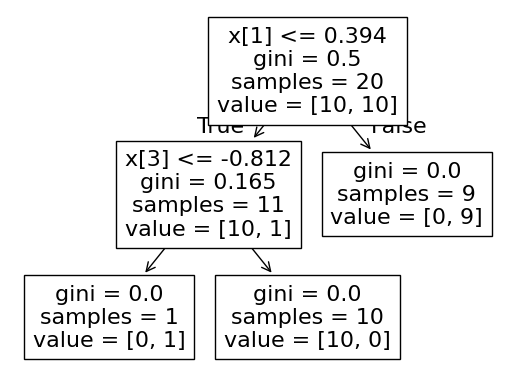

In [26]:
plot_tree(clf1)

[Text(0.6, 0.875, 'x[4] <= -0.653\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.4, 0.625, 'x[2] <= 1.403\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.6, 0.375, 'x[3] <= 1.941\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.7, 0.75, '  False')]

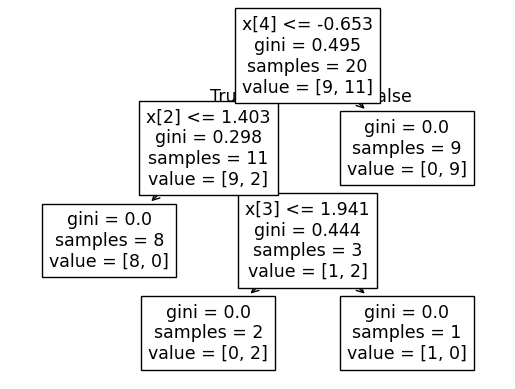

In [27]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.857\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -0.103\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]')]

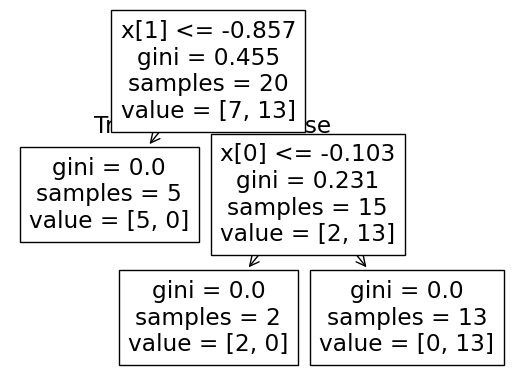

In [28]:
plot_tree(clf3)

In [29]:
 clf1.predict(np.array([1.639670, -0.266113, -0.215759, -1.818463, 2.742140]).reshape(1,5))

C:\Users\rajan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [30]:
 clf2.predict(np.array([1.639670, -0.266113, -0.215759, -1.818463, 2.742140]).reshape(1,5))

C:\Users\rajan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [31]:
 clf3.predict(np.array([1.639670, -0.266113, -0.215759, -1.818463, 2.742140]).reshape(1,5))

C:\Users\rajan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])